# K-Adapter + MAD-X 交互教学

配套 lecture: [../lectures/07-k-adapter-mad-x.md](../lectures/07-k-adapter-mad-x.md)

本 notebook 演示:
1. K-Adapter: 多类知识叠加 + 冻结切换
2. MAD-X: lang + task 解耦 + zero-shot 切换
3. Invertible adapter 数值验证

In [1]:
import sys
from pathlib import Path
import torch

src = (Path.cwd().parent / 'src').resolve()
sys.path.insert(0, str(src))

from k_adapter_minimal import MultiKnowledgeGPT2, TOY_FACTUAL_TRIPLES
from madx_minimal import MADXGPT2, InvertibleAdapter, TOY_MULTILINGUAL_DATA
from common import print_param_summary

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. K-Adapter — 多类知识

In [2]:
torch.manual_seed(42)
k_model = MultiKnowledgeGPT2(r=16, knowledge_types=('factual', 'linguistic'))
print_param_summary(k_model, 'K-Adapter (factual + linguistic)')

# 训完 factual 后冻结
k_model.freeze_adapter('factual')
after = sum(p.numel() for p in k_model.parameters() if p.requires_grad)
print(f'\n冻结 factual 后可训练: {after:,}')
print(f'→ 一半参数被冻结，符合 K-Adapter 用法')


  K-Adapter (factual + linguistic)
  Total params:       125,048,448
  Trainable params:       608,640  (0.4867%)
  Frozen params:      124,439,808

冻结 factual 后可训练: 304,320
→ 一半参数被冻结，符合 K-Adapter 用法


## 2. K-Adapter mini training on toy factual data

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


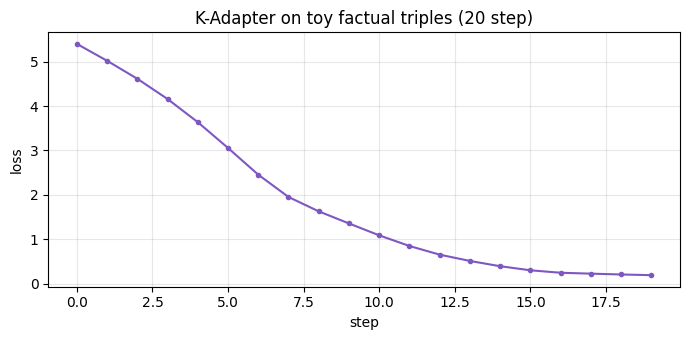

loss: 5.404 -> 0.188


In [3]:
import matplotlib.pyplot as plt
torch.manual_seed(42)
model = MultiKnowledgeGPT2(r=16, knowledge_types=('factual',))

tok = model.tokenizer
enc = tok(TOY_FACTUAL_TRIPLES[:6], return_tensors='pt', padding=True)
enc['labels'] = enc['input_ids'].clone()

opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-3)
losses = []
for step in range(20):
    opt.zero_grad()
    out = model(**enc)
    out.loss.backward()
    opt.step()
    losses.append(out.loss.item())

plt.figure(figsize=(7, 3.5))
plt.plot(losses, marker='o', markersize=3, color='#7e57c2')
plt.xlabel('step'); plt.ylabel('loss')
plt.title('K-Adapter on toy factual triples (20 step)')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f'loss: {losses[0]:.3f} -> {losses[-1]:.3f}')

## 3. Invertible Adapter — 互逆性验证

In [4]:
torch.manual_seed(42)
ia = InvertibleAdapter(d=8)
ia.log_sigma.data = torch.randn(8)  # 非平凡缩放
ia.mu.data = torch.randn(8)

x = torch.randn(2, 4, 8)
y = ia(x)
x_back = ia.inverse(y)

diff = (x - x_back).abs().max().item()
print(f'forward(x) -> y -> inverse(y) = x_back')
print(f'max |x - x_back| = {diff:.4e}')
print(f'→ 互逆性验证通过 ({"PASS" if diff < 1e-5 else "FAIL"})')

forward(x) -> y -> inverse(y) = x_back
max |x - x_back| = 2.3842e-07
→ 互逆性验证通过 (PASS)


## 4. MAD-X — 语言切换

In [5]:
torch.manual_seed(42)
madx = MADXGPT2(r=16, languages=('en', 'de', 'fr'), tasks=('ner',))
print_param_summary(madx, 'MAD-X (3 lang, 1 task)')

# 模拟训练后的 lang adapter（随机化 up）
with torch.no_grad():
    for block in madx.lm.transformer.h:
        for lang in ('en', 'de', 'fr'):
            block.mlp.language_adapters[lang].up.weight.normal_(std=0.01)

tok = madx.tokenizer
madx.eval()
enc = tok('hello world', return_tensors='pt')

logits_per_lang = {}
for lang in ('en', 'de', 'fr'):
    madx.set_active(lang, 'ner')
    with torch.no_grad():
        logits = madx(enc['input_ids'], enc['attention_mask']).logits
    logits_per_lang[lang] = logits

print('\n切换 active language 时同输入下 logits 差异:')
for l1 in ('en', 'de', 'fr'):
    for l2 in ('en', 'de', 'fr'):
        if l1 < l2:
            d = (logits_per_lang[l1] - logits_per_lang[l2]).abs().max().item()
            print(f'  {l1} vs {l2}: {d:.4e}')
print('→ 不同 lang adapter 产生不同输出，符合 MAD-X 设计')


  MAD-X (3 lang, 1 task)
  Total params:       125,661,696
  Trainable params:     1,221,888  (0.9724%)
  Frozen params:      124,439,808



切换 active language 时同输入下 logits 差异:
  en vs fr: 1.6888e+01
  de vs en: 1.5703e+01
  de vs fr: 3.4474e+00
→ 不同 lang adapter 产生不同输出，符合 MAD-X 设计


## 5. 思考题

1. 如果 K-Adapter 用 attention 融合代替 sum，参数量会增加多少？
2. MAD-X 中 lang -> task 顺序很重要。改成 task -> lang 会怎样？
3. 把 MAD-X 用到代码语言（Python/JS/Go）上，每种 language是 LA 还是 TA？

下节: **AdaMix** — MoE 路由 (本系列最后的应用方法)